# Pose Estimation Demo: „Wo sind die Gelenkpunkte?“

Bei **Pose Estimation** geht es darum, bei Personen im Bild **Keypoints** zu finden:
z.B. Schultern, Ellbogen, Handgelenke, Hüften, Knie, Knöchel.

Das Modell liefert typischerweise:
- eine Person-Detektion (ähnlich wie Detection)
- und zusätzlich **Keypoints pro Person** (x/y-Koordinaten + Konfidenz)

Wir gehen wieder Schritt für Schritt:
1) Bild laden und anschauen
2) Pose-Modell laden
3) Inferenz ausführen
4) Ergebnis untersuchen:
   - Wie viele Personen wurden gefunden?
   - Wie viele Keypoints pro Person?
   - Welche Shapes haben die Keypoint-Tensoren?
5) Alles visualisieren

In [ ]:
# relevante Packages...
!pip -q install ultralytics opencv-python matplotlib numpy

## Testbild laden: Person, die Yoga macht

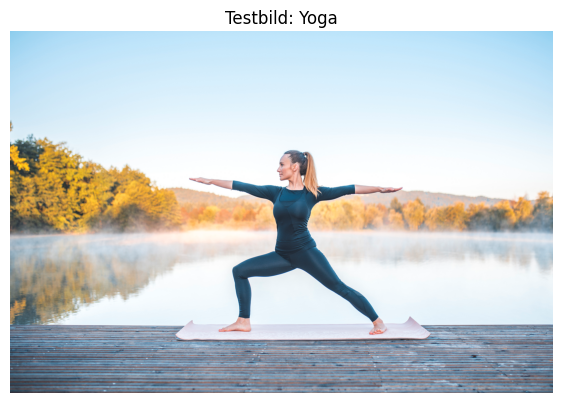

Bildshape (H, W, C): (1125, 1688, 3)


In [4]:
import cv2
import matplotlib.pyplot as plt

# Pfad anpassen!
img_path = "/home/u88m52/projects/DIH-CV/images/persons/person3.png"
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,5))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Testbild: Yoga")
plt.show()

print("Bildshape (H, W, C):", img_rgb.shape)

## Ein passendes Pose Estimation Modell laden

Wir haben das Bild geladen und angeschaut. Als nächstes laden wir ein Pose-Estimation-Modell.
Dieses Modell ist spezialisiert darauf, **Keypoints** bei Menschen zu finden.

In [5]:
from ultralytics import YOLO

pose_model = YOLO("yolo11s-pose.pt")
pose_model

YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_sta

## Das Modell auf unser Testbild anwenden...

Das Pose-Modell ist geladen - es ist wieder ein eher komplexes Modell.

Als nächstes führen wir Inferenz auf unserem Bild aus.
Danach schauen wir uns an, was `predict()` zurückliefert und welche Daten im Result stecken.

In [9]:
results = pose_model.predict(img_path, conf=0.25, verbose=False)
r0 = results[0]

print(r0)

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: ultralytics.engine.results.Keypoints object
masks: None
names: {0: 'person'}
obb: None
orig_img: array([[[239, 203, 139],
        [239, 204, 138],
        [238, 205, 136],
        ...,
        [242, 208, 143],
        [242, 208, 143],
        [241, 207, 142]],

       [[238, 204, 139],
        [238, 204, 139],
        [237, 204, 139],
        ...,
        [241, 207, 142],
        [241, 207, 142],
        [241, 207, 142]],

       [[237, 204, 139],
        [238, 205, 139],
        [237, 204, 139],
        ...,
        [240, 208, 143],
        [240, 208, 143],
        [241, 208, 143]],

       ...,

       [[ 61,  48,  46],
        [ 62,  50,  47],
        [ 63,  50,  48],
        ...,
        [115,  97,  78],
        [116,  98,  78],
        [114,  97,  78]],

       [[ 58,  47,  44],
        [ 59,  48,  47],
        [ 59,  48,  48],
        ...,
        [103,  89,  86],

Hier sehen wir wieder einige interessante Arrtibute. Wie das Detektions- und das
Segmentierungsmodell, hat auch das Pose Estimation Modell ein Attribut `boxes`, das 
Bounding Boxes für die erkannten Objekte beinhaltet. Im Kontrast zur Segmentierung haben
wir hier aber kein Attribut `masks` mehr (das ist `None`), und stattdessen ein Attribut
`keypoints`.

Da das Modell darauf trainiert wurde, die Positionen 17 anatomischer 'Landmarks' zu
identifizieren (Nase, Augen, Ohren, Schultern, Ellbögen, Handgelenke, Hüften, Knie und
Knöchel), haben diese Keypoints immer den Wert `17` in einer Dimension. 

Sehen wir uns diese Strukturen etwas genauer an:

In [10]:
if r0.boxes is not None:
    print("Anzahl Personen (boxes):", len(r0.boxes))
    print("boxes.xyxy shape:", r0.boxes.xyxy.shape)

if r0.keypoints is not None:
    print("keypoints.xy shape:", r0.keypoints.xy.shape)     # (N, K, 2)
    print("keypoints.conf shape:", r0.keypoints.conf.shape) # (N, K)

Anzahl Personen (boxes): 1
boxes.xyxy shape: torch.Size([1, 4])
keypoints.xy shape: torch.Size([1, 17, 2])
keypoints.conf shape: torch.Size([1, 17])


## Visualisierung der Ergebnisse

Wir sehen jetzt die zentrale Struktur:
- `boxes` sagt uns: wie viele Personen wurden erkannt (N)
- `keypoints` sagt uns: pro Person gibt es K=17 Gelenkpunkte (x/y) + Konfidenzen

Als nächstes visualisieren wir die Pose direkt im Bild (Skelett-Overlay).
Ultralytics kann das wieder automatisch rendern (`result.plot()`).

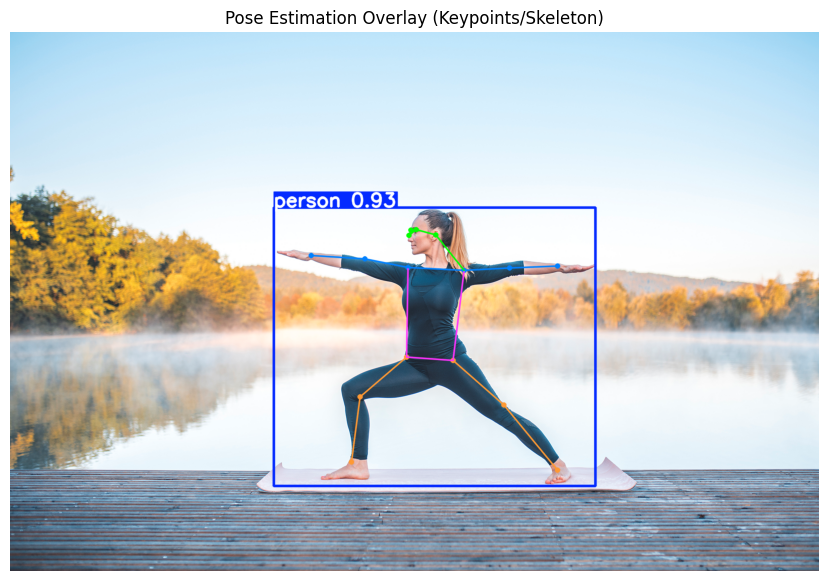

In [11]:
annotated_bgr = r0.plot()  # zeichnet Skeleton/Keypoints + ggf. Boxes
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,7))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Pose Estimation Overlay (Keypoints/Skeleton)")
plt.show()

## Resultate genauer betrachten...

Wir haben jetzt das Skeleton-Overlay gesehen – das ist die intuitive Visualisierung. Das
Modell hat es scheinbar recht gut geschafft, die Markerpunkte im Bild korrekt zu
identifizieren.

Als nächstes schauen wir in die Rohdaten. Für die detektierte Person geben wir nun die
Keypoints mit den entsprechenden Konfidenzen aus:

In [30]:
import numpy as np

xy = r0.keypoints.xy[0].cpu().numpy()
cf = r0.keypoints.conf[0].cpu().numpy()

print("Dimensionen des Inputbildes: H={}, W={}, C={}".format(img_rgb.shape[0], img_rgb.shape[1], img_rgb.shape[2]))
print("Anzahl Keypoints (K):", xy.shape[0])
for keypoint in range(xy.shape[0]):
    print(f"Keypoint: {keypoint:<18} {xy[keypoint]}, conf= {cf[keypoint]:.3f}")

# das Modell verwendet das COCO Keypoint Format
keypoint_names = ["nose", "left_eye", "right_eye", "left_ear", "right_ear",
                  "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
                  "left_wrist", "right_wrist", "left_hip", "right_hip",
                  "left_knee", "right_knee", "left_ankle", "right_ankle"]

idx, val = np.argmin(cf), np.min(cf)
print("Schlechteste Prädikion für Keypoint:", keypoint_names[idx], "mit Konfidenz:", val)

Dimensionen des Inputbildes: H=1125, W=1688, C=3
Anzahl Keypoints (K): 17
Keypoint: 0                  [     832.26      424.82], conf= 0.968
Keypoint: 1                  [     847.32      412.91], conf= 0.971
Keypoint: 2                  [     836.44      413.12], conf= 0.521
Keypoint: 3                  [     888.13      423.29], conf= 0.965
Keypoint: 4                  [     855.26       419.7], conf= 0.047
Keypoint: 5                  [      947.6      497.27], conf= 0.998
Keypoint: 6                  [     830.86      491.62], conf= 0.990
Keypoint: 7                  [       1042      492.45], conf= 0.998
Keypoint: 8                  [     740.33      473.62], conf= 0.956
Keypoint: 9                  [     1142.9         489], conf= 0.994
Keypoint: 10                 [     628.92      466.63], conf= 0.940
Keypoint: 11                 [     924.94       685.4], conf= 1.000
Keypoint: 12                 [     827.16      678.66], conf= 1.000
Keypoint: 13                 [     1030.4 

## Andere Bilder, mehrere Personen, ...

Wir sehen: pro Person kann die Anzahl zuverlässiger Keypoints variieren
(z.B. durch Occlusion, kleine Personen, Bewegungsunschärfe, etc.). Die Person am Bild
schaut zur linken Seite - das rechte Ohr ist daher nicht zu sehen. In diesem Fall ist 
der Keypoint zum rechten Ohr also aufgrund von Occlusion für das Modell nicht wahrnehmbar.

Sehen wir uns jetzt noch die Resultate für andere Bilder an:

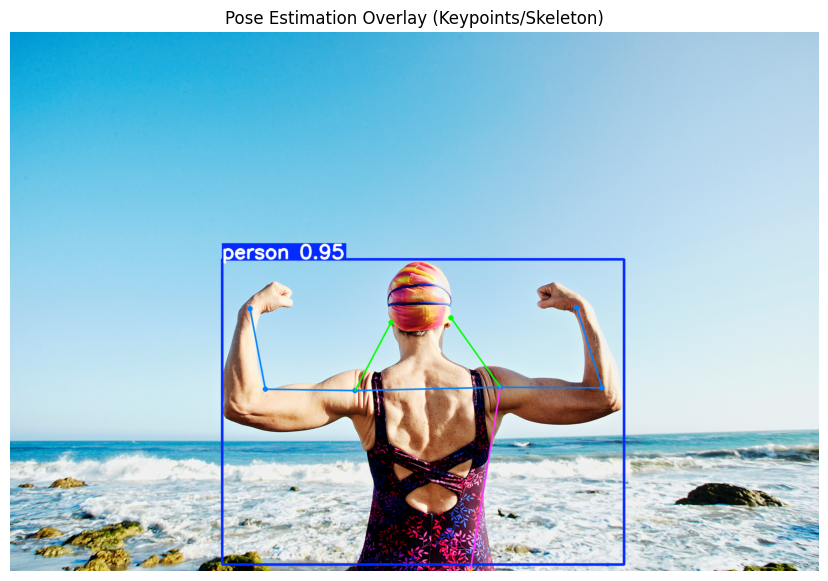

Person 0:
Keypoint: nose               [     849.93      600.88], conf= 0.073
Keypoint: left_eye           [     841.53      586.47], conf= 0.016
Keypoint: right_eye          [      861.8      576.07], conf= 0.028
Keypoint: left_ear           [     794.21      606.09], conf= 0.649
Keypoint: right_ear          [     919.63      596.36], conf= 0.819
Keypoint: left_shoulder      [     719.83      748.28], conf= 0.979
Keypoint: right_shoulder     [     1022.1      741.32], conf= 0.988
Keypoint: left_elbow         [      532.4      745.34], conf= 0.908
Keypoint: right_elbow        [     1234.4      742.02], conf= 0.964
Keypoint: left_wrist         [     500.89      577.67], conf= 0.798
Keypoint: right_wrist        [     1181.2      575.93], conf= 0.899
Keypoint: left_hip           [     787.74        1125], conf= 0.729
Keypoint: right_hip          [     960.47      1120.7], conf= 0.787
Keypoint: left_knee          [      788.1      1019.3], conf= 0.023
Keypoint: right_knee         [     910

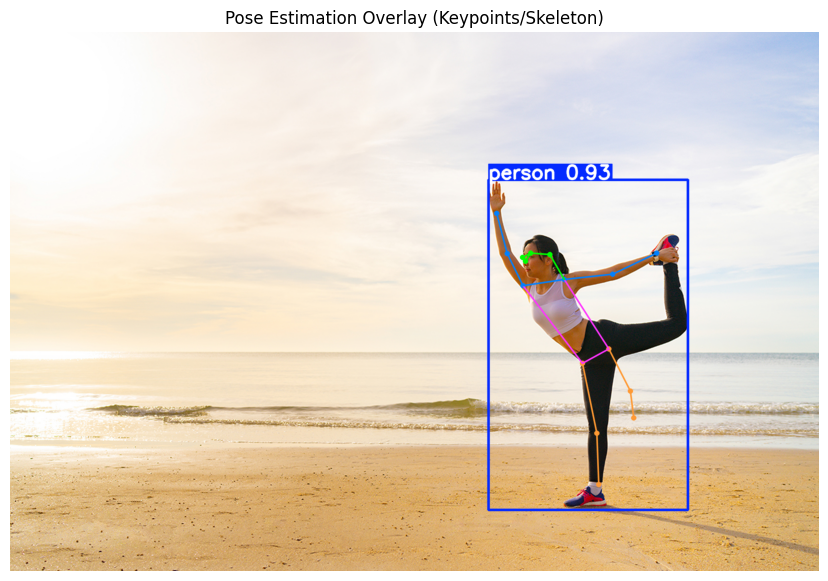

Person 0:
Keypoint: nose               [     1075.3      478.65], conf= 0.963
Keypoint: left_eye           [     1086.9      461.89], conf= 0.952
Keypoint: right_eye          [     1069.8      470.42], conf= 0.710
Keypoint: left_ear           [     1126.1      464.32], conf= 0.899
Keypoint: right_ear          [     1084.8      476.39], conf= 0.189
Keypoint: left_shoulder      [     1156.1      516.15], conf= 0.996
Keypoint: right_shoulder     [     1070.2      529.02], conf= 0.986
Keypoint: left_elbow         [     1257.8      505.74], conf= 0.991
Keypoint: right_elbow        [     1037.6      462.88], conf= 0.927
Keypoint: left_wrist         [     1349.9      461.83], conf= 0.980
Keypoint: right_wrist        [     1015.9      378.63], conf= 0.915
Keypoint: left_hip           [     1249.5      661.38], conf= 0.999
Keypoint: right_hip          [     1194.5      691.09], conf= 0.997
Keypoint: left_knee          [     1294.6      749.11], conf= 0.995
Keypoint: right_knee         [     122

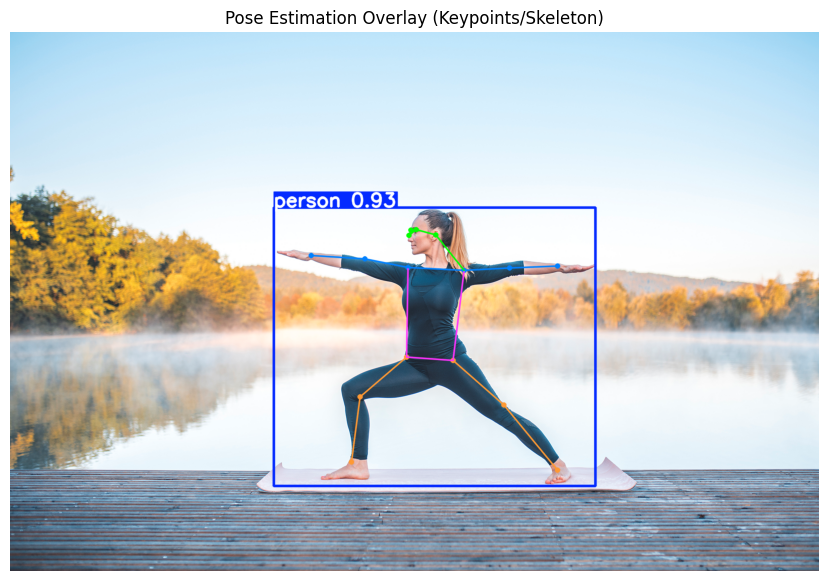

Person 0:
Keypoint: nose               [     832.26      424.82], conf= 0.968
Keypoint: left_eye           [     847.32      412.91], conf= 0.971
Keypoint: right_eye          [     836.44      413.12], conf= 0.521
Keypoint: left_ear           [     888.13      423.29], conf= 0.965
Keypoint: right_ear          [     855.26       419.7], conf= 0.047
Keypoint: left_shoulder      [      947.6      497.27], conf= 0.998
Keypoint: right_shoulder     [     830.86      491.62], conf= 0.990
Keypoint: left_elbow         [       1042      492.45], conf= 0.998
Keypoint: right_elbow        [     740.33      473.62], conf= 0.956
Keypoint: left_wrist         [     1142.9         489], conf= 0.994
Keypoint: right_wrist        [     628.92      466.63], conf= 0.940
Keypoint: left_hip           [     924.94       685.4], conf= 1.000
Keypoint: right_hip          [     827.16      678.66], conf= 1.000
Keypoint: left_knee          [     1030.4      778.22], conf= 0.999
Keypoint: right_knee         [     730

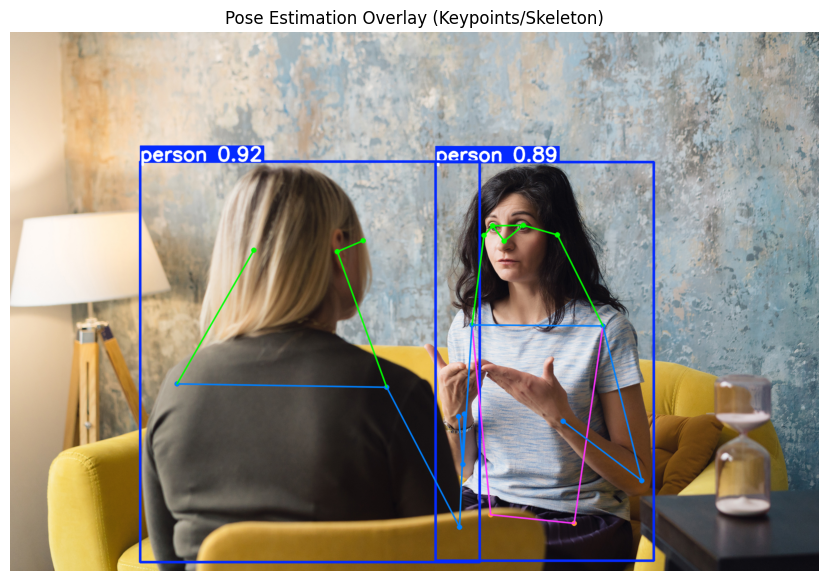

Person 0:
Keypoint: nose               [     734.38      472.36], conf= 0.219
Keypoint: left_eye           [     695.51       439.3], conf= 0.014
Keypoint: right_eye          [     736.08      435.21], conf= 0.416
Keypoint: left_ear           [     508.79      455.79], conf= 0.444
Keypoint: right_ear          [     682.46      458.08], conf= 0.998
Keypoint: left_shoulder      [     348.76      734.47], conf= 0.969
Keypoint: right_shoulder     [     785.09      741.22], conf= 0.996
Keypoint: left_elbow         [     312.53      1067.3], conf= 0.134
Keypoint: right_elbow        [      937.6        1033], conf= 0.810
Keypoint: left_wrist         [     435.76      1032.6], conf= 0.034
Keypoint: right_wrist        [     947.75      797.52], conf= 0.365
Keypoint: left_hip           [     403.84        1125], conf= 0.045
Keypoint: right_hip          [     713.14        1125], conf= 0.113
Keypoint: left_knee          [     528.93      976.41], conf= 0.006
Keypoint: right_knee         [     838

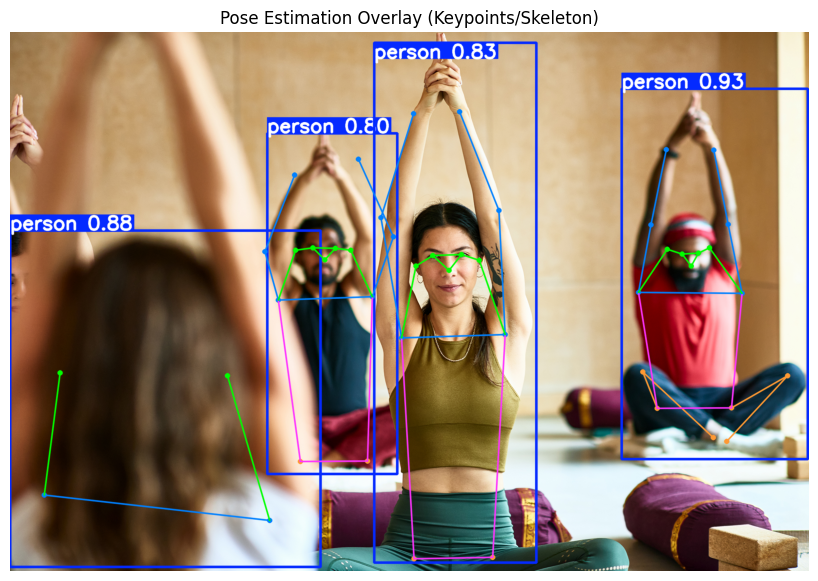

Person 0:
Keypoint: nose               [     1420.1      488.01], conf= 0.988
Keypoint: left_eye           [       1436      461.61], conf= 0.960
Keypoint: right_eye          [     1401.9      463.14], conf= 0.963
Keypoint: left_ear           [     1458.2      450.28], conf= 0.679
Keypoint: right_ear          [     1370.7      453.68], conf= 0.816
Keypoint: left_shoulder      [     1526.7      545.31], conf= 0.997
Keypoint: right_shoulder     [     1310.4      543.54], conf= 0.993
Keypoint: left_elbow         [     1497.7      401.56], conf= 0.984
Keypoint: right_elbow        [     1336.6       402.7], conf= 0.944
Keypoint: left_wrist         [     1467.3      246.87], conf= 0.963
Keypoint: right_wrist        [     1368.8      245.93], conf= 0.923
Keypoint: left_hip           [     1504.9      784.13], conf= 0.998
Keypoint: right_hip          [     1349.8      785.24], conf= 0.996
Keypoint: left_knee          [     1621.8      717.81], conf= 0.997
Keypoint: right_knee         [     131

In [35]:
img_path = "/home/u88m52/projects/DIH-CV/images/persons"
results = pose_model.predict(img_path, conf=0.25, verbose=False)

for result in results:
    annotated_bgr = result.plot()
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,7))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title("Pose Estimation Overlay (Keypoints/Skeleton)")
    plt.show()

    for k in range(len(result.keypoints.xy)):
        print(f"Person {k}:")
        xy = result.keypoints.xy[k].cpu().numpy()
        cf = result.keypoints.conf[k].cpu().numpy()
        for keypoint in range(len(keypoint_names)):
            print(f"Keypoint: {keypoint_names[keypoint]:<18} {xy[keypoint]}, conf= {cf[keypoint]:.3f}")

        idx, val = np.argmin(cf), np.min(cf)
        print("Schlechteste Prädikion für Keypoint:", keypoint_names[idx], "mit Konfidenz:", val)
    

## Zusammenfassend...

Wir haben nun gesehen:
- das Pose Estimation Modell liefert Keypoint-Koordinaten und dazugehörige Konfidenzwerte
  für 17 anatomische 'Landmarks'
- je nach Pose der Person am Bild können gewisse Marker nicht erkannt werden (nicht im
  Bild, oder durch andere Körperteile verdeckt) - für die geht dann die Konfidenz 
  entsprechend nach unten.
- YOLO nimmt uns wieder viel bei der Visualisierung ab; wir könnten recht einfach alle
  Erkenntnisse - Bounding Boxes, Keypoints, Klasse, Konfidenz - über das Originalbild
  plotten.

Ein nächster Schritt wäre dann, sich die Keypoints über mehrere Frames hinweg anzusehen
(d.h., die Pose zu **tracken**). Bevor wir uns das genauer ansehen, werfen wir allerdings
noch einen Blick auf **Oriented Bounding Boxes**.